# EDA – Kiểm tra hiệu quả Preprocessing

Mỗi section tương ứng một bước xử lý đã làm ở `preprocessing.ipynb`:
1. Tổng quan dữ liệu sau merge
2. Kiểm tra `discountAmount + userChargeAmount = amount`
3. Kiểm tra cột định danh null → `unknown`
4. Kiểm tra median imputation theo `campaignID`
5. Kiểm tra duplicate `transID`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

df = pd.read_csv('../data/processed/result_clean.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (271782, 18)
Columns: ['transID', 'userID', 'sof', 'platform', 'appID', 'deviceID', 'userIP', 'reqDate', 'amount', 'userChargeAmount', 'discountAmount', 'transStatus', 'campaignID', 'promotion_type', 'gender', 'created_account_date', 'report_cat', 'report_sub_cat']


,transID,userID,sof,platform,appID,deviceID,userIP,reqDate,amount,userChargeAmount,discountAmount,transStatus,campaignID,promotion_type,gender,created_account_date,report_cat,report_sub_cat
0,a3a41dc5672b84429dcea8d7b495ec3c,869ddd0dfb5335cba981750b64d86f5f,sof3,platform3,24,8738fc9f87128290ed8474dcb672231b,708f658693a2e43632e3953d7135502a,2022-10-23 11:36:40.380,48500,28500,20000,1,9945,voucher,male,2022-06-17,Goods_Transaction,Goods_Transaction_Platform
1,4771dea5fc29cbbff74750b8b827a68c,891db526845fb7c95ecfe6c8b187e380,sof3,platform1,748,unknown,891db526845fb7c95ecfe6c8b187e380,2022-10-22 18:13:05.372,49800,29800,20000,1,9945,voucher,male,2021-06-11,Goods_Transaction,Goods_Transaction_Platform
2,21072972ff937114bd96364f526cd9d0,b0b9e303379c38407ca75c526f1394d6,sof3,platform1,748,unknown,b0b9e303379c38407ca75c526f1394d6,2022-10-25 00:14:58.213,171175,151175,20000,1,9945,voucher,female,2021-06-04,Goods_Transaction,Goods_Transaction_Platform


---
## 1. Tổng quan sau khi Merge 3 bảng

                          Source  Matched (non-unknown)  Total  Coverage %  Unmatched
              user_info (gender)                 224410 271782       82.57      47372
user_info (created_account_date)                 271782 271782      100.00          0
      merchant_info (report_cat)                 271782 271782      100.00          0
  merchant_info (report_sub_cat)                 271782 271782      100.00          0


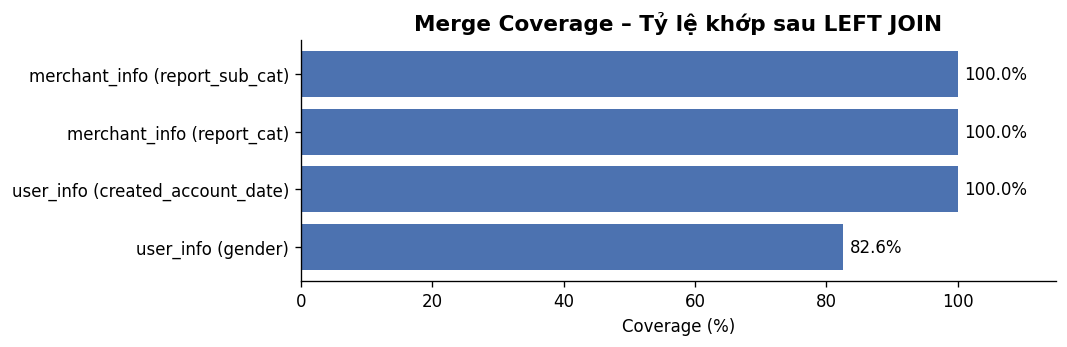

In [2]:
# ── Coverage của từng bảng sau LEFT JOIN ──────────────────────────────────────
# Cột từ user_info: gender, created_account_date
# Cột từ merchant_info: report_cat, report_sub_cat
merge_check = pd.DataFrame({
    'Source': ['user_info (gender)', 'user_info (created_account_date)', 'merchant_info (report_cat)', 'merchant_info (report_sub_cat)'],
    'Matched (non-unknown)': [
        (df['gender'] != 'unknown').sum(),
        (df['created_account_date'].notna() & (df['created_account_date'] != 'unknown')).sum(),
        (df['report_cat'] != 'unknown').sum(),
        (df['report_sub_cat'] != 'unknown').sum()
    ]
})
merge_check['Total'] = len(df)
merge_check['Coverage %'] = (merge_check['Matched (non-unknown)'] / merge_check['Total'] * 100).round(2)
merge_check['Unmatched'] = merge_check['Total'] - merge_check['Matched (non-unknown)']
print(merge_check.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3))
bars = ax.barh(merge_check['Source'], merge_check['Coverage %'], color='#4C72B0')
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_xlim(0, 115)
ax.set_xlabel('Coverage (%)')
ax.set_title('Merge Coverage – Tỷ lệ khớp sau LEFT JOIN')
plt.tight_layout()
plt.show()

---
## 2. Kiểm tra `discountAmount + userChargeAmount = amount`

✅ Hợp lệ  (discount + charge = amount): 271,782  (100.00%)
❌ Lệch    (discount + charge ≠ amount): 0  (0.00%)


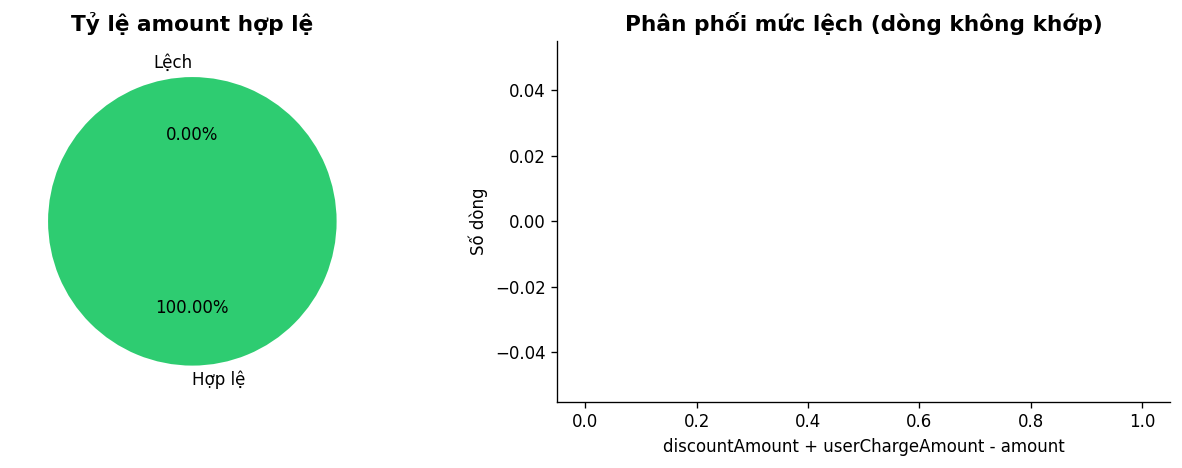


Thống kê mức lệch:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: _diff, dtype: float64


In [3]:
# ── Tỷ lệ hợp lệ ─────────────────────────────────────────────────────────────
df['amount_valid'] = (df['discountAmount'] + df['userChargeAmount'] - df['amount']).abs() < 1e-9
valid_count   = df['amount_valid'].sum()
invalid_count = (~df['amount_valid']).sum()
total = len(df)

print(f'✅ Hợp lệ  (discount + charge = amount): {valid_count:,}  ({valid_count/total*100:.2f}%)')
print(f'❌ Lệch    (discount + charge ≠ amount): {invalid_count:,}  ({invalid_count/total*100:.2f}%)')

# Tính mức độ lệch
df['_diff'] = df['discountAmount'] + df['userChargeAmount'] - df['amount']
invalid_df = df[~df['amount_valid']].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie
axes[0].pie([valid_count, invalid_count],
            labels=['Hợp lệ', 'Lệch'],
            autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[0].set_title('Tỷ lệ amount hợp lệ')

# Histogram mức lệch
axes[1].hist(invalid_df['_diff'], bins=30, color='#e74c3c', edgecolor='white')
axes[1].set_title('Phân phối mức lệch (dòng không khớp)')
axes[1].set_xlabel('discountAmount + userChargeAmount - amount')
axes[1].set_ylabel('Số dòng')

plt.tight_layout()
plt.show()

print('\nThống kê mức lệch:')
print(invalid_df['_diff'].describe().round(0))
df.drop(columns=['_diff'], inplace=True)

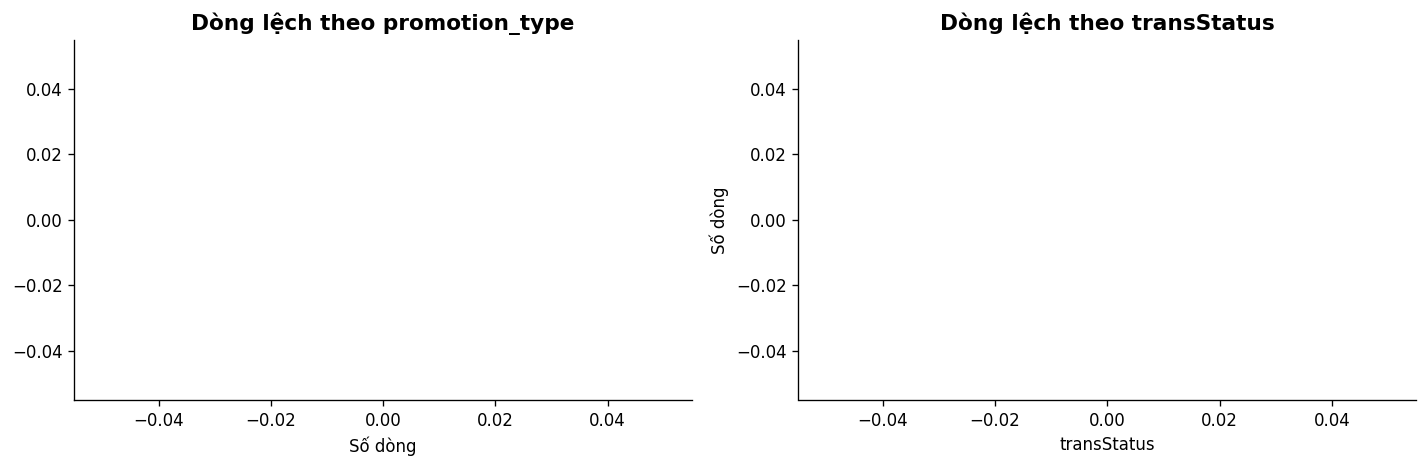

In [4]:
# ── Phân tích dòng lệch theo campaignID và promotion_type ────────────────────
invalid_df2 = df[~df['amount_valid']].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Lệch theo promotion_type
pt_counts = invalid_df2['promotion_type'].value_counts().head(10)
axes[0].barh(pt_counts.index[::-1], pt_counts.values[::-1], color='#e67e22')
axes[0].set_title('Dòng lệch theo promotion_type')
axes[0].set_xlabel('Số dòng')

# Lệch theo transStatus
ts_counts = invalid_df2['transStatus'].value_counts().head(10)
axes[1].bar(ts_counts.index.astype(str), ts_counts.values, color='#8e44ad')
axes[1].set_title('Dòng lệch theo transStatus')
axes[1].set_xlabel('transStatus')
axes[1].set_ylabel('Số dòng')

plt.tight_layout()
plt.show()

---
## 3. Kiểm tra Điền `unknown` cho cột định danh

Null còn lại sau xử lý: 0

              Column  unknown_count  null_count  unknown_%
             transID              0           0       0.00
              userID              0           0       0.00
                 sof              0           0       0.00
            platform            712           0       0.26
            deviceID          27640           0      10.17
              userIP              0           0       0.00
             reqDate              0           0       0.00
      promotion_type         170122           0      62.60
              gender          47372           0      17.43
created_account_date              0           0       0.00
          report_cat              0           0       0.00
      report_sub_cat              0           0       0.00


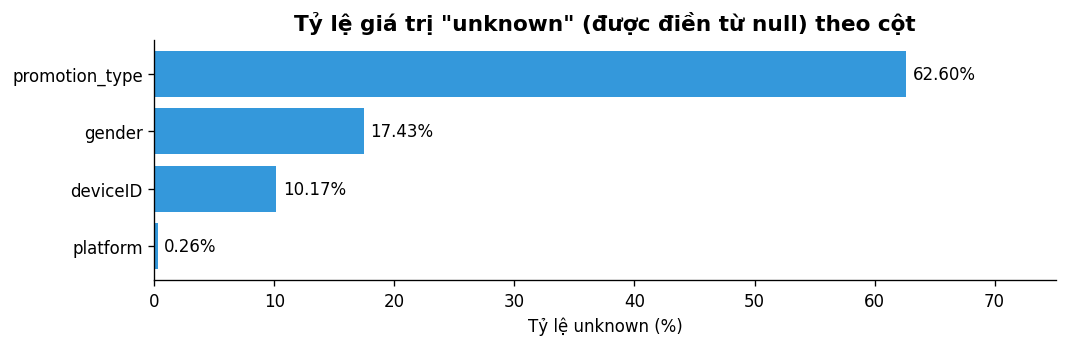

In [5]:
# ── Tỷ lệ unknown theo từng cột string ───────────────────────────────────────
obj_cols = df.select_dtypes(include='object').columns.tolist()
unknown_stats = []
for col in obj_cols:
    n_unk  = (df[col] == 'unknown').sum()
    n_null = df[col].isnull().sum()
    unknown_stats.append({'Column': col, 'unknown_count': n_unk, 'null_count': n_null,
                          'unknown_%': round(n_unk/len(df)*100, 2)})

unk_df = pd.DataFrame(unknown_stats)
print('Null còn lại sau xử lý:', df[obj_cols].isnull().sum().sum())
print()
print(unk_df.to_string(index=False))

# Chỉ vẽ cột có unknown > 0
plot_df = unk_df[unk_df['unknown_count'] > 0].sort_values('unknown_%', ascending=True)

if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(9, max(3, len(plot_df)*0.7)))
    bars = ax.barh(plot_df['Column'], plot_df['unknown_%'], color='#3498db')
    ax.bar_label(bars, fmt='%.2f%%', padding=4)
    ax.set_xlim(0, plot_df['unknown_%'].max() * 1.2)
    ax.set_xlabel('Tỷ lệ unknown (%)')
    ax.set_title('Tỷ lệ giá trị "unknown" (được điền từ null) theo cột')
    plt.tight_layout()
    plt.show()
else:
    print('✅ Không có cột nào chứa "unknown"')

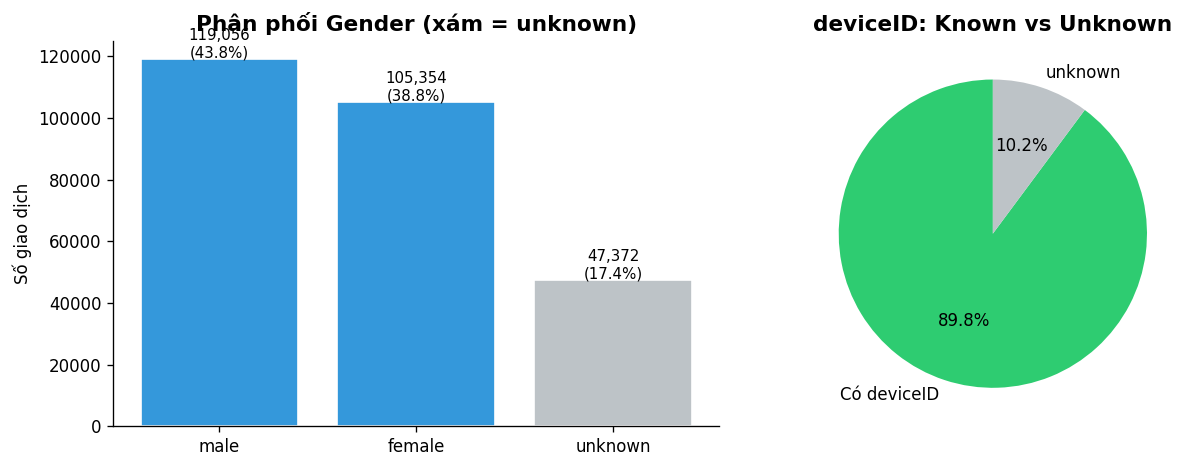

In [6]:
# ── Phân phối gender (bao gồm unknown) ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Gender distribution
g_counts = df['gender'].value_counts()
colors = ['#3498db' if v != 'unknown' else '#bdc3c7' for v in g_counts.index]
axes[0].bar(g_counts.index, g_counts.values, color=colors, edgecolor='white')
for i, v in enumerate(g_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)
axes[0].set_title('Phân phối Gender (xám = unknown)')
axes[0].set_ylabel('Số giao dịch')

# deviceID unknown
dev_known   = (df['deviceID'] != 'unknown').sum()
dev_unknown = (df['deviceID'] == 'unknown').sum()
axes[1].pie([dev_known, dev_unknown],
            labels=['Có deviceID', 'unknown'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#bdc3c7'],
            startangle=90)
axes[1].set_title('deviceID: Known vs Unknown')

plt.tight_layout()
plt.show()

---
## 4. Kiểm tra Median Imputation theo `campaignID`

Null trong cột số sau imputation:
appID               0
amount              0
userChargeAmount    0
discountAmount      0
transStatus         0
campaignID          0
dtype: int64

Tổng null: 0 ← phải = 0 ✅


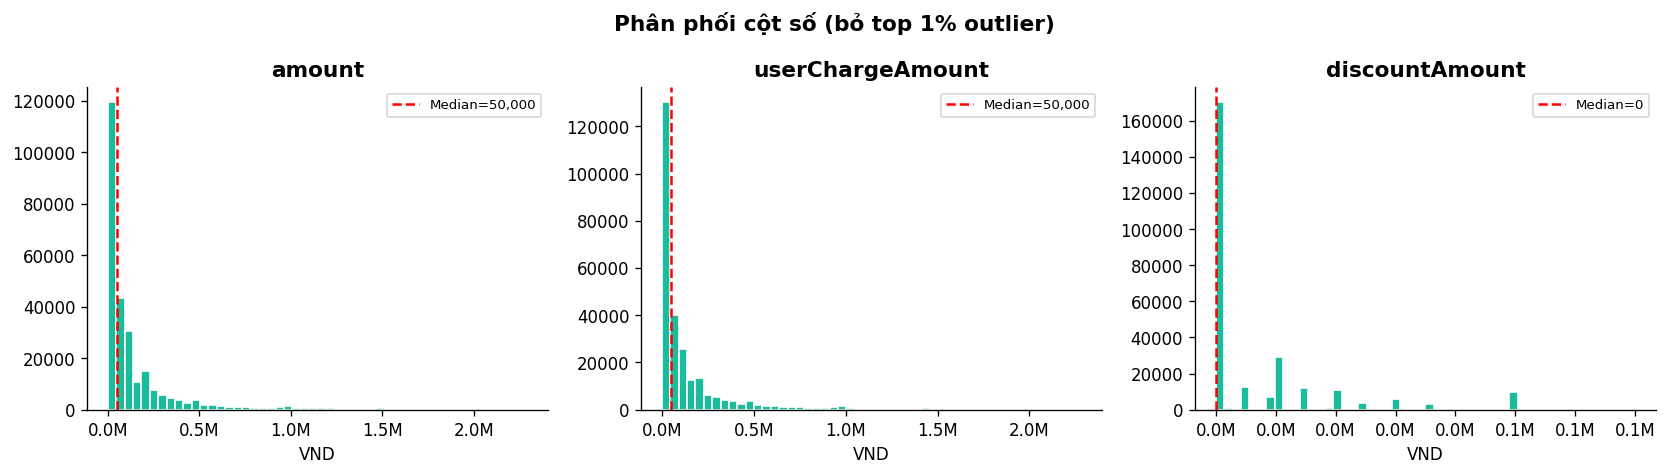

In [7]:
# ── Null còn lại trong cột số ─────────────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
null_num = df[num_cols].isnull().sum()

print('Null trong cột số sau imputation:')
print(null_num)
print(f'\nTổng null: {null_num.sum()} ← phải = 0 ✅' if null_num.sum()==0 else f'\n⚠️ Còn {null_num.sum()} null!')

# ── Phân phối amount, userChargeAmount, discountAmount ───────────────────────
money_cols = ['amount', 'userChargeAmount', 'discountAmount']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, money_cols):
    data = df[col][df[col] < df[col].quantile(0.99)]  # bỏ outlier cực trị
    ax.hist(data, bins=50, color='#1abc9c', edgecolor='white')
    ax.axvline(df[col].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median={df[col].median():,.0f}')
    ax.set_title(col)
    ax.set_xlabel('VND')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

fig.suptitle('Phân phối cột số (bỏ top 1% outlier)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

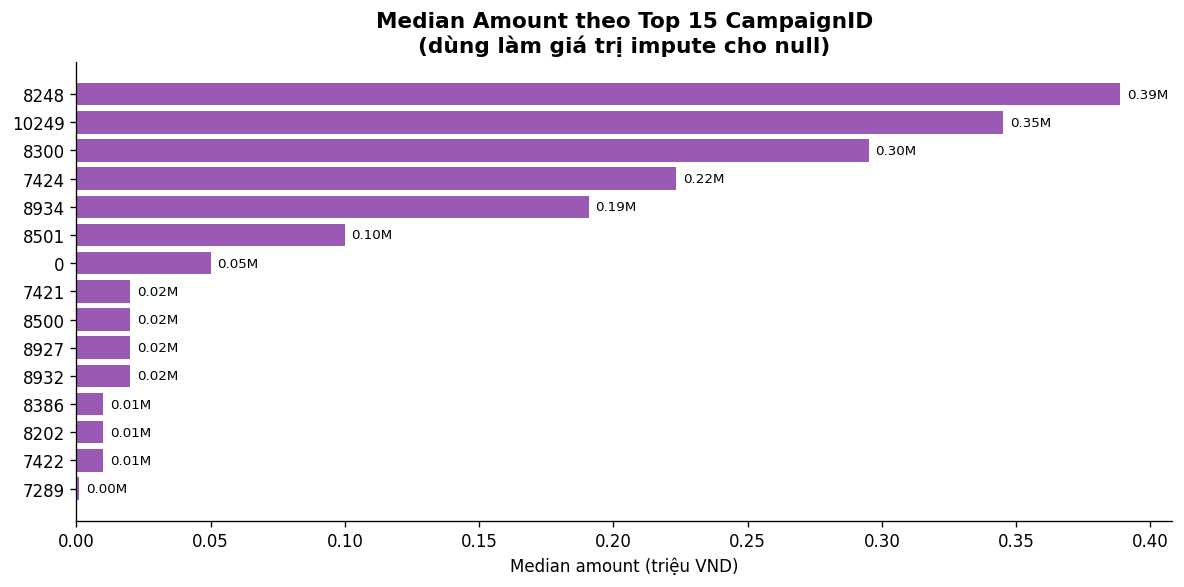

In [8]:
# ── Median amount theo top 15 campaignID ─────────────────────────────────────
top_campaigns = df['campaignID'].value_counts().head(15).index
camp_median = (df[df['campaignID'].isin(top_campaigns)]
               .groupby('campaignID')['amount']
               .median()
               .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(camp_median.index.astype(str), camp_median.values / 1e6, color='#9b59b6')
ax.bar_label(bars, fmt='%.2fM', padding=4, fontsize=8)
ax.set_xlabel('Median amount (triệu VND)')
ax.set_title('Median Amount theo Top 15 CampaignID\n(dùng làm giá trị impute cho null)')
plt.tight_layout()
plt.show()

---
## 5. Kiểm tra Duplicate `transID`

Tổng dòng        : 271,782
transID unique   : 271,782
Duplicate rows   : 0

✅ transID là khoá duy nhất – không còn duplicate!


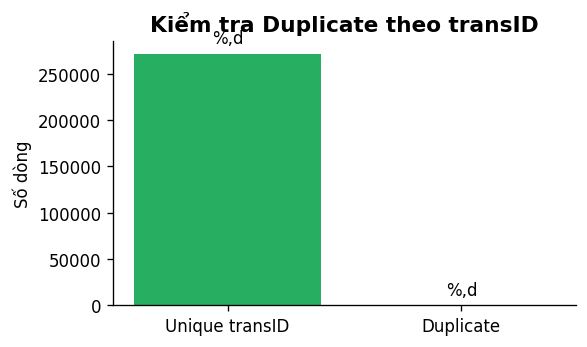

In [9]:
# ── Kiểm tra tính duy nhất của transID ───────────────────────────────────────
n_total  = len(df)
n_unique = df['transID'].nunique()
n_dup    = df.duplicated(subset='transID').sum()

print(f'Tổng dòng        : {n_total:,}')
print(f'transID unique   : {n_unique:,}')
print(f'Duplicate rows   : {n_dup:,}')
print(f'\n{"✅ transID là khoá duy nhất – không còn duplicate!" if n_dup == 0 else f"⚠️ Còn {n_dup} duplicate!"}')

# Visual confirmation
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Unique transID', 'Duplicate'], [n_unique, n_dup],
       color=['#27ae60', '#e74c3c'])
ax.bar_label(ax.containers[0], fmt='%,d', padding=4)
ax.set_title('Kiểm tra Duplicate theo transID')
ax.set_ylabel('Số dòng')
plt.tight_layout()
plt.show()

---
## 6. Tổng hợp: Dashboard kiểm tra chất lượng dữ liệu

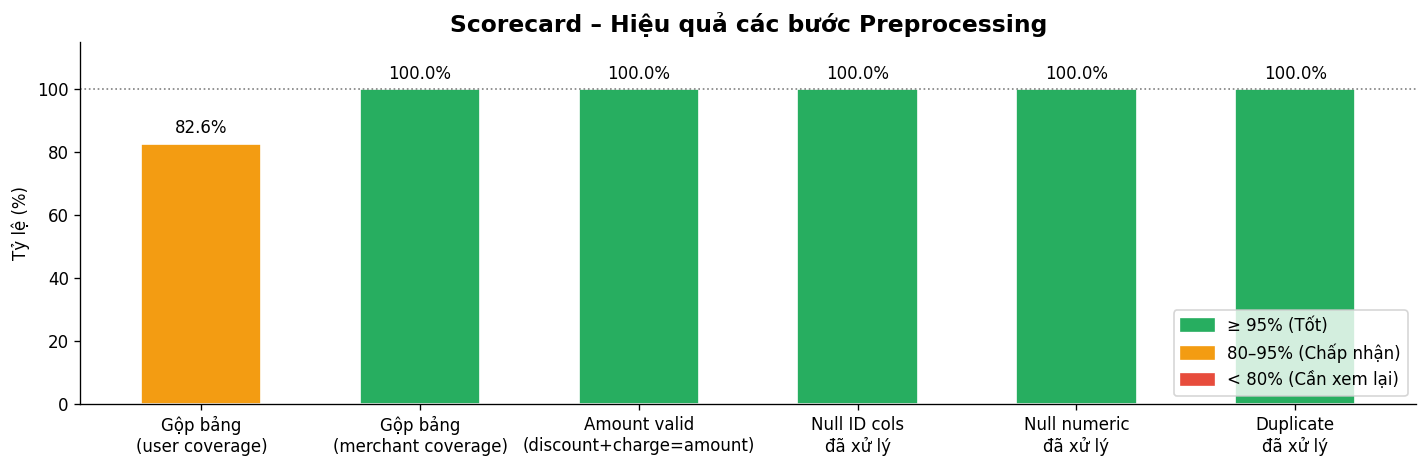


=== KẾT LUẬN ===
⚠️ Chú ý  Gộp bảng (user coverage): 82.57%
✅ Tốt  Gộp bảng (merchant coverage): 100.00%
✅ Tốt  Amount valid (discount+charge=amount): 100.00%
✅ Tốt  Null ID cols đã xử lý: 100.00%
✅ Tốt  Null numeric đã xử lý: 100.00%
✅ Tốt  Duplicate đã xử lý: 100.00%


In [10]:
# ── Summary scorecard ─────────────────────────────────────────────────────────
total = len(df)

checks = {
    'Gộp bảng\n(user coverage)':    (df['gender'] != 'unknown').sum() / total * 100,
    'Gộp bảng\n(merchant coverage)': (df['report_cat'] != 'unknown').sum() / total * 100,
    'Amount valid\n(discount+charge=amount)': df['amount_valid'].sum() / total * 100,
    'Null ID cols\nđã xử lý':        100.0,   # đã điền unknown, không còn null
    'Null numeric\nđã xử lý':        100.0,   # đã điền median, không còn null
    'Duplicate\nđã xử lý':           100.0 if df.duplicated('transID').sum() == 0 else 0.0
}

labels = list(checks.keys())
values = list(checks.values())
colors = ['#27ae60' if v >= 95 else '#f39c12' if v >= 80 else '#e74c3c' for v in values]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(labels, values, color=colors, width=0.55, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel('Tỷ lệ (%)')
ax.set_title('Scorecard – Hiệu quả các bước Preprocessing', fontsize=14)
ax.axhline(100, color='grey', linestyle=':', linewidth=1)

from matplotlib.patches import Patch
legend = [Patch(color='#27ae60', label='≥ 95% (Tốt)'),
          Patch(color='#f39c12', label='80–95% (Chấp nhận)'),
          Patch(color='#e74c3c', label='< 80% (Cần xem lại)')]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

print('\n=== KẾT LUẬN ===')
for label, val in zip(labels, values):
    status = '✅ Tốt' if val >= 95 else '⚠️ Chú ý' if val >= 80 else '❌ Cần xem lại'
    print(f'{status}  {label.replace(chr(10)," ")}: {val:.2f}%')